In [165]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [166]:
df = pd.read_csv('hotel_bookings.csv')

In [167]:
#Dropping company because it is missing 94% of entries
df.drop(columns=['company'], inplace=True)

#removing dupicate entries
df.drop_duplicates(inplace=True)

#dropping if the booking result because dont want to give answer to model
df.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)

#dropping any entries if there is no country
df = df.dropna(subset=['country'])


In [168]:
#filling the the remaining missing/null values
df['agent'] = df['agent'].fillna(0)
df['children'] = df['children'].fillna(0)

#had Null values so is a float --> convert to an int because AgentID and # of children are integers
df['agent'] = df['agent'].astype(int)
df['children'] = df['children'].astype(int)

#print(df.isna().sum())

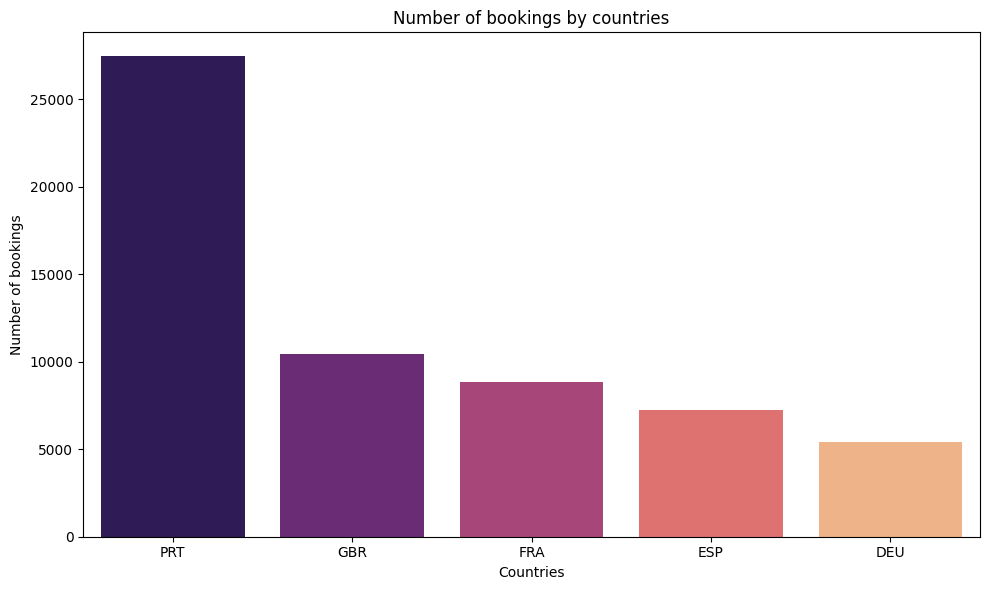

In [169]:
#top 5 countries with the most bookings
country_bookings = df['country'].value_counts().head(5)

plt.figure(figsize=(10,6))
sns.barplot(x=country_bookings.index, y=country_bookings.values, hue=country_bookings.index, palette='magma')
plt.xlabel('Countries')
plt.ylabel('Number of bookings')
plt.title('Number of bookings by countries')
plt.tight_layout()

plt.show()

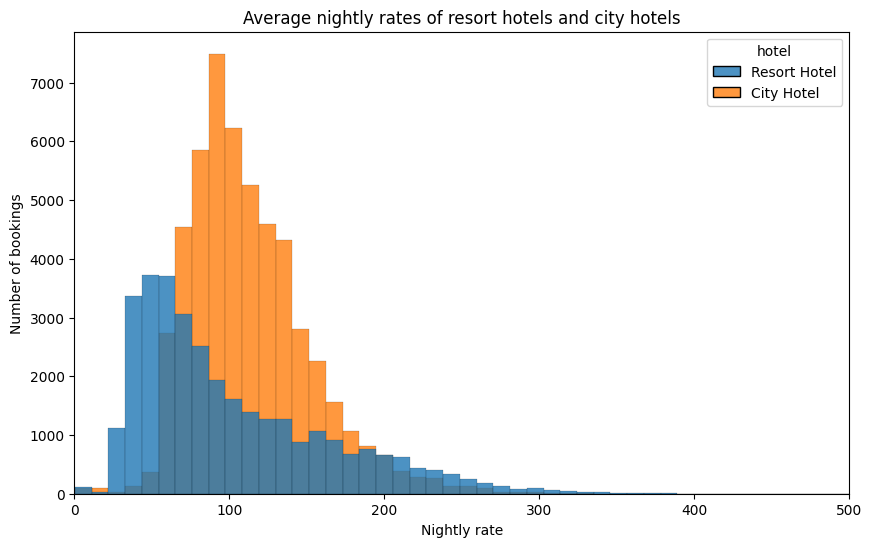

In [170]:
#resort hotel vs city hotels on average
filtered = df[df['adr'] > 0] #filtering out freestays/canceled bookings
plt.figure(figsize=(10,6))

sns.histplot(data=filtered, x='adr', hue='hotel', bins=500, alpha=0.8)
plt.xlim(0,500)
plt.xlabel('Nightly rate')
plt.ylabel('Number of bookings')
plt.title('Average nightly rates of resort hotels and city hotels')

plt.show()


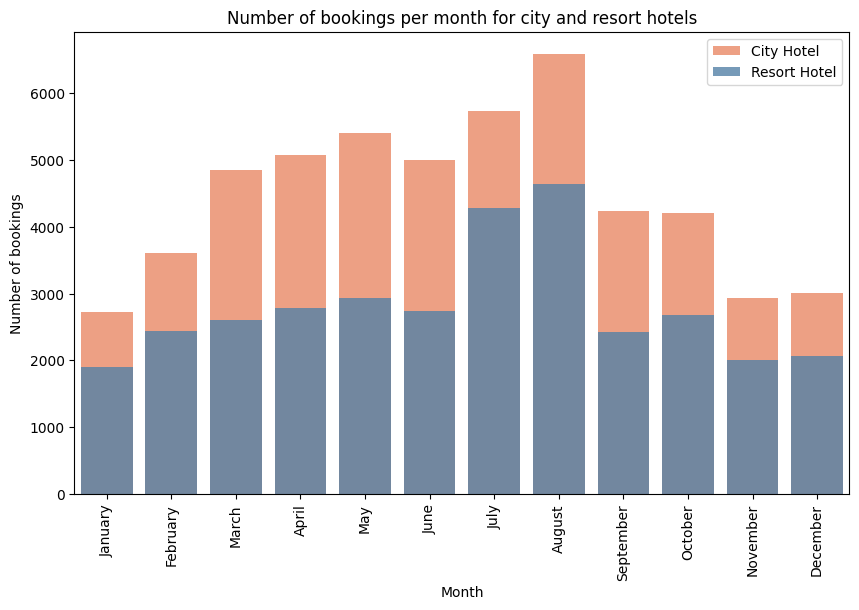

In [171]:
plt.figure(figsize=(10,6))

months = ['January','February','March','April','May','June', 'July','August','September','October','November','December']

city_counts = df[df['hotel'] == 'City Hotel']['arrival_date_month'].value_counts().reindex(months)
resort_counts = df[df['hotel'] == 'Resort Hotel']['arrival_date_month'].value_counts().reindex(months)

sns.barplot(x=months, y=city_counts, alpha = 0.8, label = 'City Hotel', color = 'coral')
sns.barplot(x=months, y=resort_counts, alpha=0.8, label = 'Resort Hotel', color = 'steelblue')

plt.xlabel("Month")
plt.ylabel("Number of bookings")
plt.title("Number of bookings per month for city and resort hotels")
plt.xticks(rotation=90)

plt.show()

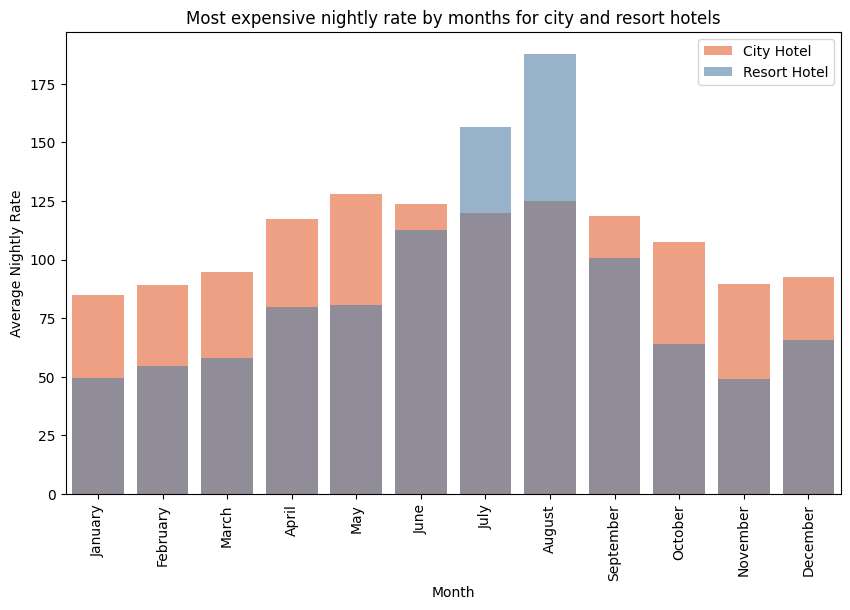

In [172]:
plt.figure(figsize=(10,6))

months = ['January','February','March','April','May','June', 'July','August','September','October','November','December']

city_costs = df[df['hotel'] == 'City Hotel'].groupby('arrival_date_month')['adr'].mean().reindex(months)
resort_costs = df[df['hotel'] == 'Resort Hotel'].groupby('arrival_date_month')['adr'].mean().reindex(months)

sns.barplot(x=months, y=city_costs, alpha = 0.8, label = 'City Hotel', color = 'coral')
sns.barplot(x=months, y=resort_costs, alpha= 0.6, label = 'Resort Hotel', color = 'steelblue')

plt.xlabel("Month")
plt.ylabel("Average Nightly Rate")
plt.title("Most expensive nightly rate by months for city and resort hotels")
plt.xticks(rotation=90)

plt.show()

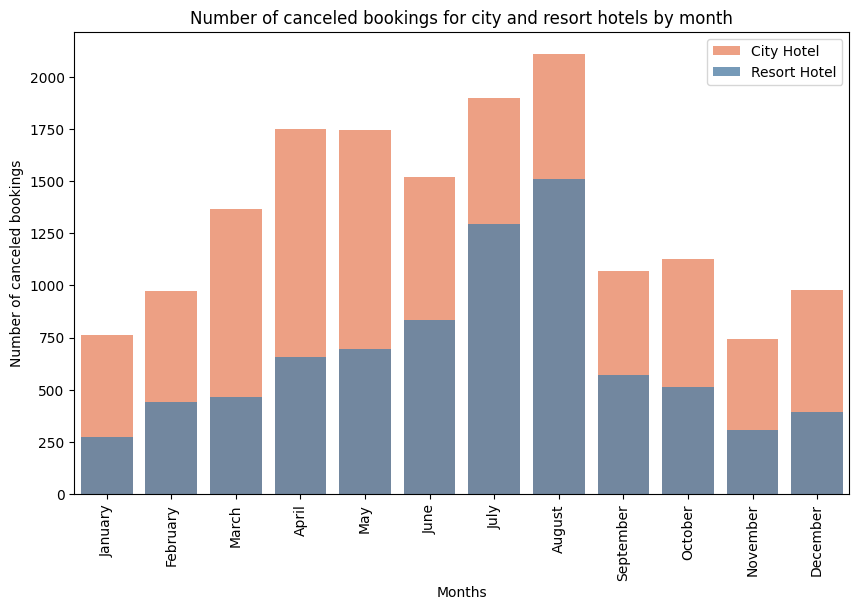

In [173]:
plt.figure(figsize=(10,6))

months = ['January','February','March','April','May','June', 'July','August','September','October','November','December']

canceled_bookings = df[df['is_canceled'] == 1]
city_canceled = canceled_bookings[canceled_bookings['hotel'] == 'City Hotel']['arrival_date_month'].value_counts().reindex(months)
resort_canceled = canceled_bookings[canceled_bookings['hotel'] == 'Resort Hotel']['arrival_date_month'].value_counts().reindex(months)

sns.barplot(x=months, y=city_canceled, alpha = 0.8, label = 'City Hotel', color = 'coral')
sns.barplot(x=months, y=resort_canceled, alpha= 0.8, label = 'Resort Hotel', color = 'steelblue')

plt.xlabel("Months")
plt.ylabel("Number of canceled bookings")
plt.title("Number of canceled bookings for city and resort hotels by month")
plt.xticks(rotation=90)

plt.show()

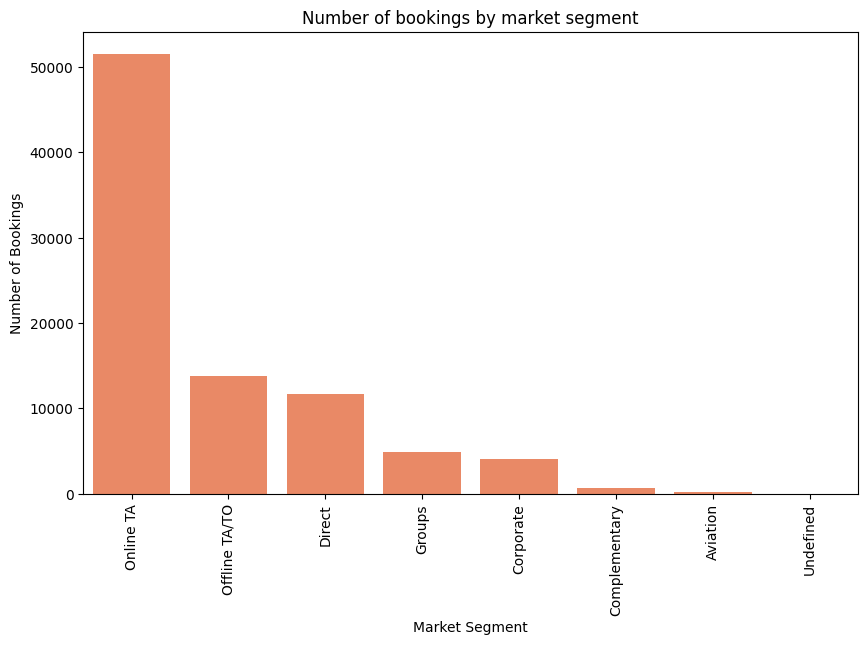

In [174]:
plt.figure(figsize=(10, 6))

segment_counts = df['market_segment'].value_counts()

sns.barplot(x=segment_counts.index, y=segment_counts.values, color='coral')

plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.title('Number of bookings by market segment')
plt.xticks(rotation=90)

plt.show()

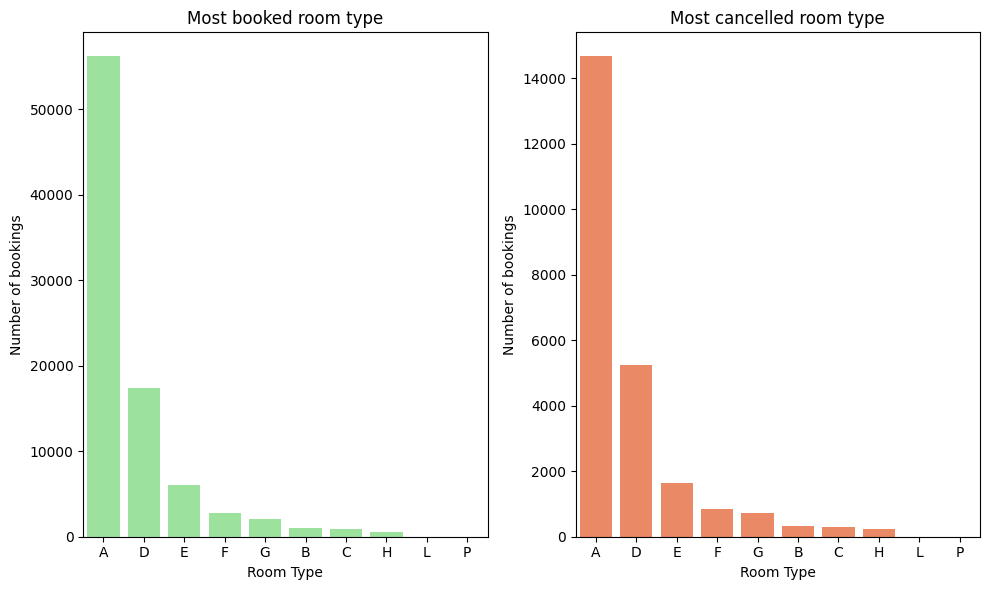

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

booked_rooms = df['reserved_room_type'].value_counts()
cancelled_rooms = df[df['is_canceled'] == 1]['reserved_room_type'].value_counts()

sns.barplot(x=booked_rooms.index, y=booked_rooms.values, color='lightgreen', ax=axes[0])
axes[0].set_title('Most booked room type')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Number of bookings')

sns.barplot(x=cancelled_rooms.index, y=cancelled_rooms.values, color='coral', ax=axes[1])
axes[1].set_title('Most cancelled room type')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Number of bookings')

plt.tight_layout()
plt.show()

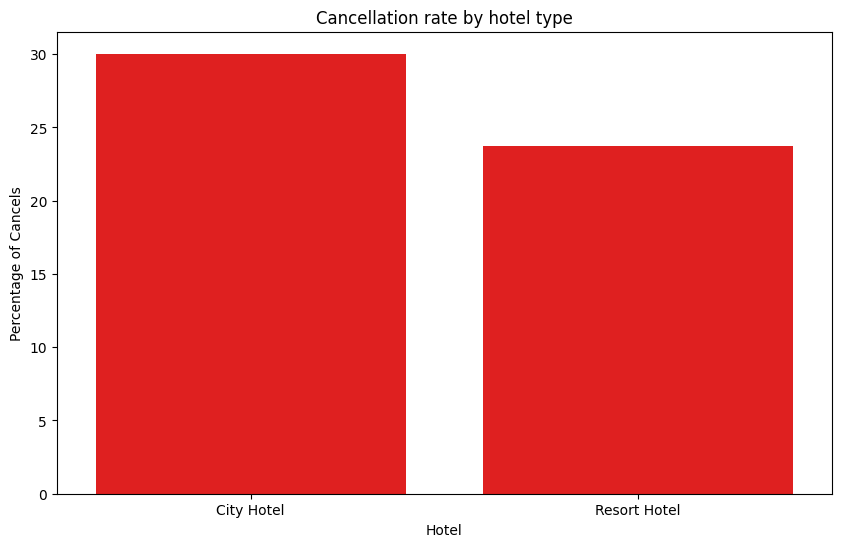

In [176]:
plt.figure(figsize=(10, 6))

cancel_percentages = df.groupby('hotel')['is_canceled'].mean() * 100

sns.barplot(x=cancel_percentages.index, y=cancel_percentages.values, color='red')

plt.xlabel('Hotel')
plt.ylabel('Percentage of Cancels')
plt.title('Cancellation rate by hotel type')

plt.show()

In [177]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [178]:
#hotel: 2 unique values
#arrival_date_month: 12 unique values
#meal: 5 unique values
#country: 177 unique values
#market_segment: 8 unique values
#distribution_channel: 5 unique values
#reserved_room_type: 10 unique values
#assigned_room_type: 12 unique values
#deposit_type: 3 unique values
#customer_type: 4 unique values

#making a copy because I need to drop country before encoding and make new cols
#because country has 177 unique values so it would make too many cols
df_copy = df.drop(columns=['country']) 

pre_encoded_colums = ['hotel', 'arrival_date_month', 
                      'meal', 'market_segment',
                      'distribution_channel', 'reserved_room_type',
                      'assigned_room_type', 'deposit_type',
                      'customer_type']

#making the dummy columns for the unique values
df_model = pd.get_dummies(df_copy, columns=pre_encoded_colums, drop_first=True)

#dropping the solution to actually
X = df_model.drop(columns=['is_canceled'])
y = df_model['is_canceled']

#splitting data into 70% training and 30% testing + validation
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=67)

#splitting the 30% into testing and validation 15%|15%
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=67)


In [179]:
#im zscoring the inputs so that huge inputs like the number of days when booking was made
#wont influence as much so like 300 days --> 2.5 sd
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#training the logistic regression model over 1000 iterations
logistic_regression_model = LogisticRegression(max_iter=1000)
logistic_regression_model.fit(X_train_scaled, y_train)

logistic_regression_prediction = logistic_regression_model.predict(X_test_scaled)

print(f'Accuracy:  {accuracy_score(y_test, logistic_regression_prediction):.4f}')
print(f'Precision: {precision_score(y_test, logistic_regression_prediction):.4f}')
print(f'Recall:    {recall_score(y_test, logistic_regression_prediction):.4f}')
print(f'F1 Score:  {f1_score(y_test, logistic_regression_prediction):.4f}')

Accuracy:  0.7969
Precision: 0.7011
Recall:    0.4262
F1 Score:  0.5302


/Users/alvinshao/CSE351ProjectSP26/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alvinshao/CSE351ProjectSP26/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alvinshao/CSE351ProjectSP26/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alvinshao/CSE351ProjectSP26/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/alvinshao/CSE351ProjectSP26/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in 

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = df.drop(columns=['is_canceled'])
y = df['is_canceled']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

y_pred = rf_model.predict(X_test)

print("\n--- Final Performance ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

: 